# Patrón 8: Human-in-the-Loop (HITL)

### ¿Qué es?
El patrón **Human-in-the-Loop** permite que el workflow **pause** en puntos críticos para que un humano revise, apruebe, corrija o redirija la ejecución. LangGraph implementa esto nativamente con `interrupt()` y checkpointing.

Caso de Uso: Aprobación de Préstamos

Dataset: [Loan Approval Prediction Dataset](https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset) — Kaggle
Columnas clave: loan_id, no_of_dependents, education, self_employed, income_annum, loan_amount, loan_term, cibil_score, residential_assets_value, commercial_assets_value, luxury_assets_value, bank_asset_value, loan_status

Dependencias:
```bash
!pip install langgraph langchain langchain-anthropic langchain-openai \
             pandas scikit-learn kaggle --quiet
```

Diagrama:

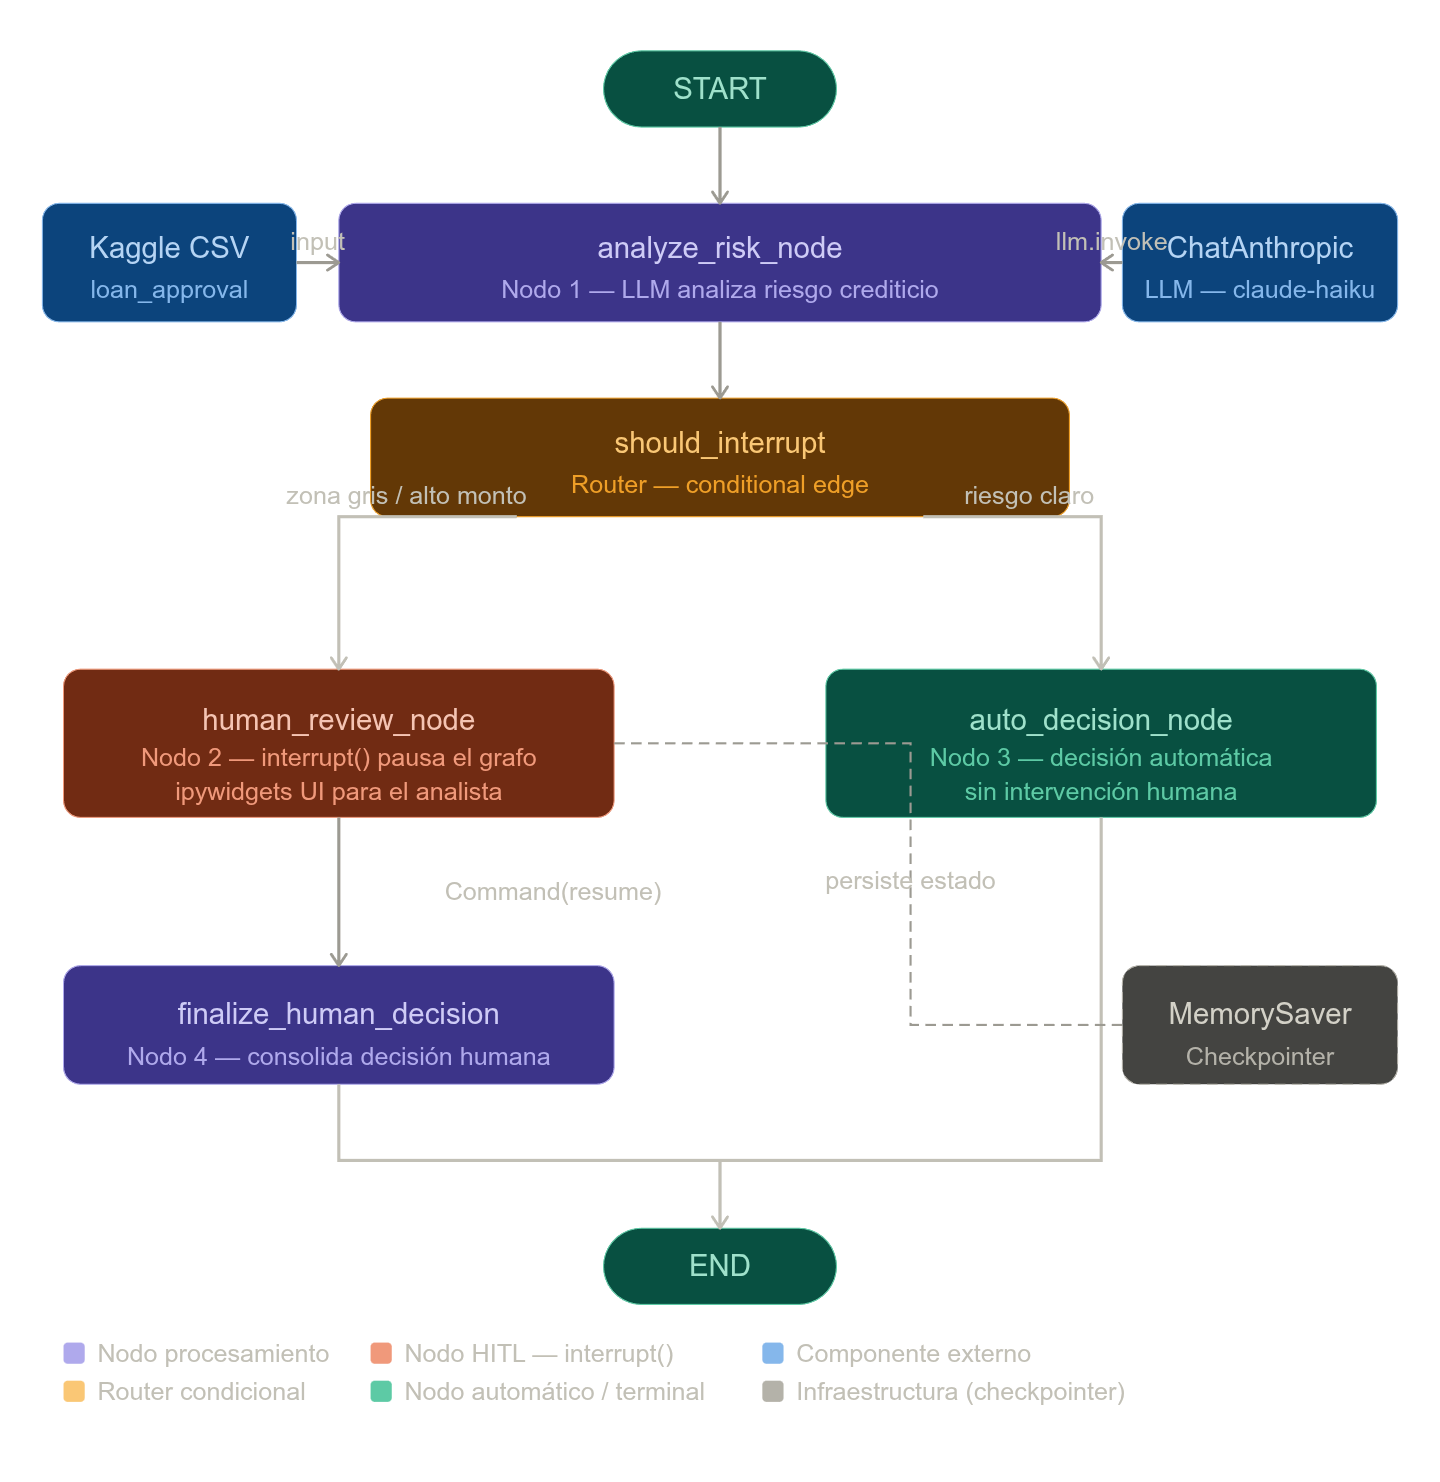


Nodos:

|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|START|Terminal|Punto de entrada del grafo|Nodo virtual de LangGraph que inicia la ejecución. Conecta directamente con analyze_risk_node mediante un edge estático.|
|analyze_risk_node|Nodo LLM|Análisis de riesgo crediticio|Invoca el LLM con los datos del solicitante y un prompt estructurado. Produce risk_score, risk_level, ai_recommendation y ai_reasoning en formato JSON. Es el único nodo que llama al modelo.|
|should_interrupt|Router condicional|Decide si requiere revisión humana|Conditional edge que evalúa risk_level == "medium", loan_amount > 25M, ai_recommendation == "review" o riesgo crítico aprobado por IA. Enruta a human_review o auto_decision.|
|human_review_node|Nodo HITL|Pausa y captura decisión humana|Ejecuta interrupt(payload), serializando el estado completo en el checkpointer. El grafo se congela hasta que el analista responde vía ipywidgets (RadioButtons + Textarea + botón). Al reanudar recibe Command(resume={decision, feedback}).|
|auto_decision_node|Nodo automático|Decisión sin intervención humana|Para solicitudes de riesgo bajo o crítico claro. Toma la ai_recommendation directamente como final_decision y registra en decision_log con source: "ai_automatic". No llama al LLM.|
|finalize_human_decision|Nodo procesamiento|Consolida la decisión del analista|Recibe human_decision y human_feedback del state restaurado post-interrupt. Escribe final_decision con source: "human_override" y agrega la entrada final al decision_log.|
|END|Terminal|Punto de salida del grafo|Nodo virtual de LangGraph que finaliza la ejecución. Ambas ramas (HITL y automática) convergen aquí. Al alcanzarlo, graph.invoke() retorna el state completo.|
|LoanApplicationState|State (TypedDict)|Estado compartido del grafo|Estructura de datos tipada con TypedDict que fluye entre nodos. Contiene: datos del solicitante, métricas de riesgo IA, decisión humana, final_decision y decision_log (audit trail).|
|MemorySaver|Checkpointer|Persistencia del estado entre invocaciones|Componente obligatorio para usar interrupt(). Serializa el state completo en memoria (SQLite o Postgres en producción) indexado por thread_id. Permite reanudar el grafo desde el punto exacto de pausa.|
|ChatAnthropic|LLM|Modelo de lenguaje para análisis|Instancia de claude-haiku-4-5 via LangChain. Solo se usa en analyze_risk_node. Recibe el prompt con los datos del solicitante y retorna JSON con el análisis de riesgo. Temperatura 0 para resultados deterministas.|
|Kaggle Dataset|Fuente de datos|Datos de entrada del pipeline|Dataset Loan Approval Prediction (architsharma01, 4.269 filas, 13 columnas). Descargado vía Kaggle API. Cada fila es una solicitud de préstamo con CIBIL score, ingresos, monto, activos y estado de aprobación.|
|ipywidgets UI|Interfaz HITL|Panel de revisión para el analista|Interfaz Jupyter con RadioButtons, Textarea y Button. Muestra el resumen del solicitante, las métricas IA y las violaciones de política. El click en "Confirmar" ejecuta graph.invoke(Command(resume=...)) para reanudar el grafo.|
|Command(resume)|Primitivo LangGraph|Reanuda el grafo post-interrupt|Objeto especial de LangGraph que se pasa a graph.invoke() junto con el config del thread original. Lleva el payload {decision, feedback} del humano y restaura la ejecución desde el nodo human_review_node.|

### Cuándo usarlo
- ✅ Acciones irreversibles (eliminar datos, enviar emails masivos, deploy)
- ✅ Procesos de aprobación multi-nivel (compliance, finanzas)
- ✅ Agentes con acceso a sistemas críticos de producción
- ❌ Workflows de alta frecuencia donde la latencia humana es inaceptable

In [1]:
!pip install langgraph langchain langchain-anthropic langchain-openai \
             pandas scikit-learn kaggle --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

### Descarga de dataset

In [2]:
# ============================================================
# CELDA 2 — Descarga del dataset desde Kaggle
# Prerequisito: tener ~/.kaggle/kaggle.json con tu API key
# https://www.kaggle.com/settings → API → Create New Token
# ============================================================
import os

# Opción A: descarga vía Kaggle API CLI
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Si no tienes kaggle.json configurado, descomenta y completa:
# kaggle_json = '{"username":"TU_USUARIO","key":"TU_API_KEY"}'
# with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
#     f.write(kaggle_json)
# os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

!kaggle datasets download -d architsharma01/loan-approval-prediction-dataset --unzip -p ./data/

print("✅ Dataset descargado en ./data/")

Dataset URL: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset
License(s): MIT
100%|███████████████████████████████████████| 80.6k/80.6k [00:00<00:00, 236kB/s]

✅ Dataset descargado en ./data/


In [3]:
# ============================================================
# CELDA 3 — Alternativa: crear dataset sintético realista
# (sin necesidad de API Key de Kaggle — mismo esquema)
# ============================================================
import pandas as pd
import numpy as np

np.random.seed(42)
N = 50  # trabajamos con 50 solicitudes para el demo

data = {
    "loan_id": [f"LP{str(i).zfill(3)}" for i in range(1, N + 1)],
    "no_of_dependents": np.random.randint(0, 6, N),
    "education": np.random.choice(["Graduate", "Not Graduate"], N),
    "self_employed": np.random.choice(["Yes", "No"], N),
    "income_annum": np.random.randint(200_000, 9_900_000, N),
    "loan_amount": np.random.randint(300_000, 39_500_000, N),
    "loan_term": np.random.choice([2, 4, 6, 8, 10, 12, 16, 20], N),
    "cibil_score": np.random.randint(300, 900, N),
    "residential_assets_value": np.random.randint(100_000, 29_000_000, N),
    "commercial_assets_value": np.random.randint(0, 10_000_000, N),
    "luxury_assets_value": np.random.randint(0, 15_000_000, N),
    "bank_asset_value": np.random.randint(0, 15_000_000, N),
}

# Lógica aproximada del target: aprobado si cibil_score > 650
# y loan_amount < income_annum * 5
df = pd.DataFrame(data)
df["loan_status"] = df.apply(
    lambda r: "Approved"
    if (r["cibil_score"] > 650 and r["loan_amount"] < r["income_annum"] * 5)
    else "Rejected",
    axis=1,
)

print(df.shape)
df.head(10)

(50, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,LP001,3,Not Graduate,Yes,3947389,2535000,12,871,24790913,445101,1004646,10074901,Approved
1,LP002,4,Not Graduate,No,4342807,23985747,6,301,27280308,8106609,14243011,14932828,Rejected
2,LP003,2,Not Graduate,Yes,8188004,38176684,16,603,11426237,7413023,9360133,7006454,Rejected
3,LP004,4,Graduate,No,6445035,6122184,20,553,19334400,7613269,3867500,3612610,Rejected
4,LP005,4,Not Graduate,Yes,3802279,34257122,20,752,28409787,1105534,12772319,7031883,Rejected
5,LP006,1,Graduate,Yes,5715989,30159174,2,336,20980238,9972201,449395,2164367,Rejected
6,LP007,2,Not Graduate,No,2321690,36402853,2,459,1518175,9613273,5143901,10292658,Rejected
7,LP008,2,Not Graduate,No,691234,12495226,8,308,20683904,4353127,6754350,144356,Rejected
8,LP009,2,Not Graduate,Yes,5601218,2254109,6,532,15659675,7315360,1260386,12786773,Rejected
9,LP010,4,Graduate,No,7114550,14721668,12,398,16000476,8073461,3054390,11487928,Rejected


### Exploración básica del dataset

In [4]:
# ============================================================
# CELDA 4 — Exploración básica del dataset
# ============================================================
print("=== Distribución de loan_status ===")
print(df["loan_status"].value_counts())
print()
print("=== Estadísticas descriptivas ===")
print(df[["income_annum", "loan_amount", "cibil_score", "loan_term"]].describe())
print()

# Casos de zona gris: cibil_score entre 580 y 700
# Estos son los candidatos perfectos para HITL
zone_gray = df[(df["cibil_score"] >= 580) & (df["cibil_score"] <= 720)]
print(f"Solicitudes en zona gris (CIBIL 580-720): {len(zone_gray)}")
print(zone_gray[["loan_id", "cibil_score", "income_annum", "loan_amount", "loan_status"]].head(10))

=== Distribución de loan_status ===
loan_status
Rejected    39
Approved    11
Name: count, dtype: int64

=== Estadísticas descriptivas ===
       income_annum   loan_amount  cibil_score  loan_term
count  5.000000e+01  5.000000e+01    50.000000  50.000000
mean   4.867488e+06  1.912611e+07   567.020000   9.840000
std    2.634991e+06  1.165161e+07   176.310659   6.437644
min    2.435850e+05  3.610870e+05   301.000000   2.000000
25%    2.831426e+06  9.362263e+06   421.750000   4.500000
50%    5.443218e+06  1.803374e+07   542.500000   8.000000
75%    6.905323e+06  2.942111e+07   715.000000  16.000000
max    9.802083e+06  3.822652e+07   886.000000  20.000000

Solicitudes en zona gris (CIBIL 580-720): 10
   loan_id  cibil_score  income_annum  loan_amount loan_status
2    LP003          603       8188004     38176684    Rejected
12   LP013          703       7106726     23534510    Approved
17   LP018          719       8087739     13322704    Approved
27   LP028          637       7264746    

### Configuración del LLM (Anthropic / OpenAI)

In [ ]:
# ── Patch compatibilidad: langchain-core vs paquete `langchain` ───────────────
# langchain-core consulta globals (verbose/debug/llm_cache) en el módulo `langchain`.
# Si esa versión no los expone -> AttributeError ("module 'langchain' has no
# attribute 'verbose'"). Ejecuta esta celda ANTES de instanciar ChatAnthropic.
import langchain
import langchain_core.globals as _lcg
for _attr, _default in (("verbose", False), ("debug", False), ("llm_cache", None)):
    if not hasattr(langchain, _attr):
        setattr(langchain, _attr, _default)
for _name, _fb in (("get_verbose", False), ("get_llm_cache", None)):
    _orig = getattr(_lcg, _name, None)
    if _orig is not None:
        def _make(orig, fb):
            def _patched():
                try:
                    return orig()
                except AttributeError:
                    return fb
            return _patched
        setattr(_lcg, _name, _make(_orig, _fb))
print("✅ patch compatibilidad langchain aplicado")


In [5]:
# ============================================================
# CELDA 5 — Configuración del LLM (Anthropic / OpenAI)
# ============================================================
import os
from dotenv import load_dotenv
load_dotenv()


from langchain_anthropic import ChatAnthropic
# from langchain_openai import ChatOpenAI  # alternativa

llm = ChatAnthropic(model="claude-sonnet-4-20250514", temperature=0)
# llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print(f"✅ LLM configurado: {llm.model}")

✅ LLM configurado: claude-sonnet-4-20250514


### Definición del State del grafo HITL

In [6]:
# ============================================================
# CELDA 6 — Definición del State del grafo HITL
# ============================================================
from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, MessagesState, START, END

class LoanApplicationState(TypedDict):
    # Datos de la solicitud
    loan_id: str
    applicant_data: dict

    # Análisis del agente
    risk_score: float          # 0.0 a 1.0 (mayor = más riesgo)
    risk_level: str            # "low" | "medium" | "high" | "critical"
    ai_recommendation: str     # "approve" | "reject" | "review"
    ai_reasoning: str

    # Decisión humana (llenada por interrupt)
    human_decision: Optional[str]   # "approve" | "reject" | "request_info"
    human_feedback: Optional[str]

    # Resultado final
    final_decision: Optional[str]
    decision_log: list[dict]

print("✅ State definido: LoanApplicationState")

✅ State definido: LoanApplicationState


### Nodo 1: Análisis de riesgo por el agente IA

In [7]:
# ============================================================
# CELDA 7 — Nodo 1: Análisis de riesgo por el agente IA
# ============================================================
import json

RISK_ANALYSIS_PROMPT = """
Eres un agente experto en análisis de riesgo crediticio. Analiza la siguiente
solicitud de préstamo y determina el nivel de riesgo.

SOLICITUD:
{applicant_data}

CRITERIOS DE EVALUACIÓN:
- CIBIL Score < 500: riesgo crítico
- CIBIL Score 500-620: alto riesgo
- CIBIL Score 620-720: riesgo medio (REQUIERE REVISIÓN HUMANA)
- CIBIL Score > 720: bajo riesgo

- Ratio préstamo/ingreso > 6x: señal de alerta
- Sin empleo formal (self_employed=Yes) + alto monto: señal de alerta
- Sin educación universitaria + CIBIL bajo: señal adicional

RESPONDE ÚNICAMENTE con un objeto JSON válido (sin markdown, sin texto extra):
{{
    "risk_score": <float entre 0.0 y 1.0>,
    "risk_level": "<low|medium|high|critical>",
    "ai_recommendation": "<approve|reject|review>",
    "ai_reasoning": "<explicación concisa de máximo 100 palabras>"
}}
"""

def analyze_risk_node(state: LoanApplicationState) -> dict:
    """Nodo 1: El agente IA analiza el riesgo crediticio."""
    print(f"\n🤖 [AGENTE] Analizando solicitud {state['loan_id']}...")

    prompt = RISK_ANALYSIS_PROMPT.format(
        applicant_data=json.dumps(state["applicant_data"], ensure_ascii=False, indent=2)
    )

    response = llm.invoke(prompt)
    raw_text = response.content.strip()

    # Parsear JSON de la respuesta
    try:
        analysis = json.loads(raw_text)
    except json.JSONDecodeError:
        # Fallback si el LLM no retorna JSON puro
        import re
        match = re.search(r"\{.*\}", raw_text, re.DOTALL)
        analysis = json.loads(match.group()) if match else {
            "risk_score": 0.5,
            "risk_level": "medium",
            "ai_recommendation": "review",
            "ai_reasoning": "Error en análisis — requiere revisión manual."
        }

    print(f"   Risk Score: {analysis['risk_score']:.2f}")
    print(f"   Risk Level: {analysis['risk_level'].upper()}")
    print(f"   Recomendación IA: {analysis['ai_recommendation'].upper()}")
    print(f"   Razonamiento: {analysis['ai_reasoning'][:80]}...")

    return {
        "risk_score": analysis["risk_score"],
        "risk_level": analysis["risk_level"],
        "ai_recommendation": analysis["ai_recommendation"],
        "ai_reasoning": analysis["ai_reasoning"],
        "decision_log": state.get("decision_log", []) + [{
            "step": "ai_analysis",
            "loan_id": state["loan_id"],
            "risk_score": analysis["risk_score"],
            "recommendation": analysis["ai_recommendation"]
        }]
    }

print("✅ Nodo analyze_risk_node definido")

✅ Nodo analyze_risk_node definido


### Router: ¿Necesita revisión humana?

In [8]:
# ============================================================
# CELDA 8 — Router: ¿Necesita revisión humana?
# ============================================================

def should_interrupt(state: LoanApplicationState) -> Literal["human_review", "auto_decision"]:
    """
    Determina si la solicitud debe ir a revisión humana.
    Umbral de monto ajustado: > 25,000,000 (para que LP001 sea automática)
    """
    risk_level = state["risk_level"]
    loan_amount = state["applicant_data"].get("loan_amount", 0)
    recommendation = state["ai_recommendation"]

    requires_human = (
        risk_level == "medium"
        or recommendation == "review"
        or loan_amount > 25_000_000          # ← subido de 10M a 25M
        or (risk_level == "critical" and recommendation == "approve")
    )

    if requires_human:
        print(f"\n⚠️  [ROUTER] {state['loan_id']} → REQUIERE REVISIÓN HUMANA")
        print(f"   Motivo: risk_level={risk_level}, loan_amount={loan_amount:,}, rec={recommendation}")
        return "human_review"
    else:
        print(f"\n✅ [ROUTER] {state['loan_id']} → Decisión automática ({recommendation.upper()})")
        return "auto_decision"

print("✅ Router should_interrupt definido")

✅ Router should_interrupt definido


### Nodo 2: interrupt() — Pausa para revisión humana

In [9]:
# ============================================================
# CELDA 9 — Nodo 2: interrupt() — Pausa para revisión humana
# ============================================================
from langgraph.types import interrupt, Command

def human_review_node(state: LoanApplicationState) -> dict:
    """
    Nodo 2: Pausa la ejecución para que un humano revise.

    El interrupt() serializa el estado completo en el checkpointer
    y retorna el control al código externo. La ejecución se
    reanuda cuando se llama graph.invoke(Command(resume=...)).
    """
    applicant = state["applicant_data"]

    # Payload presentado al humano — puede ser una UI, Slack, email, etc.
    review_payload = {
        "solicitud": state["loan_id"],
        "resumen_applicante": {
            "CIBIL Score": applicant.get("cibil_score"),
            "Ingreso Anual": f"${applicant.get('income_annum', 0):,}",
            "Monto Solicitado": f"${applicant.get('loan_amount', 0):,}",
            "Plazo": f"{applicant.get('loan_term')} años",
            "Empleo": applicant.get("self_employed", "N/A"),
            "Educación": applicant.get("education", "N/A"),
        },
        "analisis_ia": {
            "risk_score": state["risk_score"],
            "risk_level": state["risk_level"],
            "recomendacion": state["ai_recommendation"],
            "razonamiento": state["ai_reasoning"],
        },
        "instrucciones": (
            "Responde con un dict: "
            "{'decision': 'approve'|'reject'|'request_info', "
            "'feedback': 'comentario opcional'}"
        )
    }

    print("\n" + "="*60)
    print("🛑 INTERRUPT — REVISIÓN HUMANA REQUERIDA")
    print("="*60)
    print(json.dumps(review_payload, ensure_ascii=False, indent=2))
    print("="*60)

    # *** PUNTO DE INTERRUPCIÓN ***
    # El grafo pausa aquí. El objeto review_payload es el "question"
    # que se expone al humano. La ejecución se congela hasta que
    # se llame: graph.invoke(Command(resume={"decision": ..., "feedback": ...}))
    human_response = interrupt(review_payload)

    print(f"\n👤 [HUMANO] Decisión recibida: {human_response}")

    return {
        "human_decision": human_response.get("decision"),
        "human_feedback": human_response.get("feedback", ""),
        "decision_log": state.get("decision_log", []) + [{
            "step": "human_review",
            "loan_id": state["loan_id"],
            "human_decision": human_response.get("decision"),
            "feedback": human_response.get("feedback", "")
        }]
    }

print("✅ Nodo human_review_node definido con interrupt()")

✅ Nodo human_review_node definido con interrupt()


### Nodo 3: Decisión automática (sin interrupción)

In [10]:
# ============================================================
# CELDA 10 — Nodo 3: Decisión automática (sin interrupción)
# ============================================================

def auto_decision_node(state: LoanApplicationState) -> dict:
    """
    Nodo 3: Decisiones automáticas para solicitudes de bajo/alto riesgo claro.
    No requiere intervención humana.
    """
    decision = state["ai_recommendation"]
    print(f"\n🤖 [AUTO-DECISION] {state['loan_id']}: {decision.upper()} (automático)")

    return {
        "final_decision": decision,
        "decision_log": state.get("decision_log", []) + [{
            "step": "auto_decision",
            "loan_id": state["loan_id"],
            "final_decision": decision,
            "source": "ai_automatic"
        }]
    }

print("✅ Nodo auto_decision_node definido")

✅ Nodo auto_decision_node definido


### Nodo 4: Consolidar decisión humana

In [11]:
# ============================================================
# CELDA 11 — Nodo 4: Consolidar decisión humana
# ============================================================

def finalize_human_decision_node(state: LoanApplicationState) -> dict:
    """
    Nodo 4: Consolida la decisión humana en el estado final.
    Si el humano pide más info, el agente puede volver a analizar.
    """
    human_decision = state.get("human_decision", "reject")

    print(f"\n✅ [FINAL] Solicitud {state['loan_id']}: decisión humana → {human_decision.upper()}")
    if state.get("human_feedback"):
        print(f"   Feedback: {state['human_feedback']}")

    return {
        "final_decision": human_decision,
        "decision_log": state.get("decision_log", []) + [{
            "step": "finalize",
            "loan_id": state["loan_id"],
            "final_decision": human_decision,
            "source": "human_override"
        }]
    }

print("✅ Nodo finalize_human_decision_node definido")

✅ Nodo finalize_human_decision_node definido


### Construcción del grafo HITL

In [12]:
# ============================================================
# CELDA 12 — Construcción del grafo HITL
# ============================================================
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# Checkpointer: en memoria para el demo
# En producción usar: PostgresSaver o SqliteSaver
checkpointer = MemorySaver()

builder = StateGraph(LoanApplicationState)

# Registrar nodos
builder.add_node("analyze_risk",     analyze_risk_node)
builder.add_node("human_review",     human_review_node)
builder.add_node("auto_decision",    auto_decision_node)
builder.add_node("finalize_human",   finalize_human_decision_node)

# Edges
builder.add_edge(START, "analyze_risk")

# Edge condicional: ¿requiere HITL?
builder.add_conditional_edges(
    "analyze_risk",
    should_interrupt,
    {
        "human_review":  "human_review",
        "auto_decision": "auto_decision",
    }
)

# Después de revisión humana → finalizar
builder.add_edge("human_review",  "finalize_human")
builder.add_edge("finalize_human", END)
builder.add_edge("auto_decision",  END)

# Compilar con checkpointer (obligatorio para interrupt())
graph = builder.compile(checkpointer=checkpointer)

print("✅ Grafo HITL compilado correctamente")
print(f"   Nodos: {list(graph.nodes.keys())}")

✅ Grafo HITL compilado correctamente
   Nodos: ['__start__', 'analyze_risk', 'human_review', 'auto_decision', 'finalize_human']


### Visualizar el grafo (requiere graphviz)

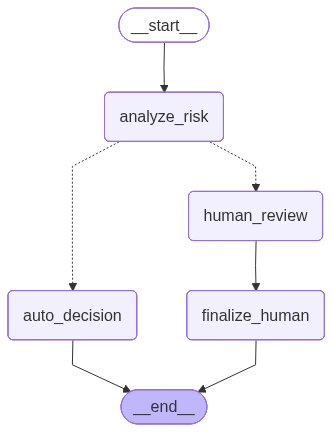

In [13]:
# ============================================================
# CELDA 13 — Visualizar el grafo (requiere graphviz)
# ============================================================
# pip install grandalf   ← alternativa ASCII si no hay graphviz

try:
    from IPython.display import Image, display
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception as e:
    # Fallback: representación ASCII
    print(graph.get_graph().draw_ascii())
    print(f"(Nota: instala graphviz para imagen PNG. Error: {e})")

### DEMO 1: Caso de decisión AUTOMÁTICA (bajo riesgo)

Solicitud con CIBIL alto, ratio bueno → aprobación automática

In [14]:
# ============================================================
# CELDA 14 — DEMO 1: Caso de decisión AUTOMÁTICA (bajo riesgo)
# Solicitud con CIBIL alto, ratio bueno → aprobación automática
# ============================================================
from langgraph.types import Command

# Solicitud de bajo riesgo: CIBIL 780, ratio 2.5x
applicant_low_risk = {
    "loan_id": "LP001",
    "no_of_dependents": 1,
    "education": "Graduate",
    "self_employed": "No",
    "income_annum": 5_000_000,
    "loan_amount": 12_500_000,    # ratio 2.5x ← bajo riesgo
    "loan_term": 10,
    "cibil_score": 780,
    "residential_assets_value": 20_000_000,
    "commercial_assets_value": 5_000_000,
    "luxury_assets_value": 2_000_000,
    "bank_asset_value": 8_000_000,
}

config_1 = {"configurable": {"thread_id": "loan-LP001"}}

print("=" * 60)
print("DEMO 1: Solicitud de BAJO RIESGO (decisión automática)")
print("=" * 60)

initial_state = {
    "loan_id": "LP001",
    "applicant_data": applicant_low_risk,
    "human_decision": None,
    "human_feedback": None,
    "final_decision": None,
    "decision_log": [],
}

result = graph.invoke(initial_state, config_1)

print(f"\n🎯 RESULTADO FINAL: {result['final_decision'].upper()}")
print(f"   Risk Score: {result['risk_score']:.2f}")
print(f"   Decision Log: {len(result['decision_log'])} pasos")

DEMO 1: Solicitud de BAJO RIESGO (decisión automática)

🤖 [AGENTE] Analizando solicitud LP001...
   Risk Score: 0.25
   Risk Level: LOW
   Recomendación IA: APPROVE
   Razonamiento: Perfil crediticio sólido con CIBIL score excelente (780), indicando historial de...

✅ [ROUTER] LP001 → Decisión automática (APPROVE)

🤖 [AUTO-DECISION] LP001: APPROVE (automático)

🎯 RESULTADO FINAL: APPROVE
   Risk Score: 0.25
   Decision Log: 2 pasos


### DEMO 2: Caso de REVISIÓN HUMANA (zona gris)

CIBIL 650 (zona media), monto alto → interrupt()

In [15]:
# ============================================================
# CELDA 15 (REESCRITA) — DEMO 2: Zona Gris + Interacción Humana
# con ipywidgets para revisión real en Jupyter Notebook
# pip install ipywidgets (si no está instalado)
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output
from langgraph.types import Command
import json

applicant_gray_zone = {
    "loan_id": "LP042",
    "no_of_dependents": 3,
    "education": "Not Graduate",
    "self_employed": "Yes",
    "income_annum": 2_800_000,
    "loan_amount": 14_000_000,
    "loan_term": 8,
    "cibil_score": 658,
    "residential_assets_value": 8_000_000,
    "commercial_assets_value": 0,
    "luxury_assets_value": 3_500_000,
    "bank_asset_value": 2_000_000,
}

config_2 = {"configurable": {"thread_id": "loan-LP042-v2"}}

initial_state_2 = {
    "loan_id": "LP042",
    "applicant_data": applicant_gray_zone,
    "human_decision": None,
    "human_feedback": None,
    "final_decision": None,
    "decision_log": [],
}

# ── Paso 1: invocar el grafo (se detendrá en interrupt) ──────
print("🚀 Iniciando análisis de solicitud LP042...")
result_partial = graph.invoke(initial_state_2, config_2)

ai_data = {
    "risk_score":       result_partial.get("risk_score", "?"),
    "risk_level":       result_partial.get("risk_level", "?"),
    "ai_recommendation": result_partial.get("ai_recommendation", "?"),
    "ai_reasoning":     result_partial.get("ai_reasoning", ""),
}

# ── Paso 2: construir la UI de revisión humana ───────────────

# Colores por nivel de riesgo
risk_colors = {
    "low":      "#2ea44f",
    "medium":   "#e3b341",
    "high":     "#f78166",
    "critical": "#cf222e",
}
rec_icons = {"approve": "✅", "reject": "❌", "review": "⚠️"}
risk_color = risk_colors.get(ai_data["risk_level"], "#888")

# Panel de información
info_html = widgets.HTML(value=f"""
<div style="font-family:monospace; border:2px solid {risk_color};
            border-radius:8px; padding:16px; background:#0d1117; color:#c9d1d9;
            max-width:640px; margin-bottom:12px;">
  <h3 style="color:{risk_color}; margin-top:0;">
    🛑 REVISIÓN HUMANA — Solicitud LP042
  </h3>
  <table style="width:100%; border-collapse:collapse; font-size:13px;">
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:4px 8px; color:#8b949e;">CIBIL Score</td>
      <td style="padding:4px 8px; color:#e6edf3; font-weight:bold;">
        {applicant_gray_zone['cibil_score']}
      </td>
      <td style="padding:4px 8px; color:#8b949e;">Ingreso Anual</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        ${applicant_gray_zone['income_annum']:,}
      </td>
    </tr>
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:4px 8px; color:#8b949e;">Monto Solicitado</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        ${applicant_gray_zone['loan_amount']:,}
      </td>
      <td style="padding:4px 8px; color:#8b949e;">Plazo</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        {applicant_gray_zone['loan_term']} años
      </td>
    </tr>
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:4px 8px; color:#8b949e;">Empleo</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        {applicant_gray_zone['self_employed']}
      </td>
      <td style="padding:4px 8px; color:#8b949e;">Educación</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        {applicant_gray_zone['education']}
      </td>
    </tr>
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:4px 8px; color:#8b949e;">Ratio Deuda/Ingreso</td>
      <td style="padding:4px 8px; color:#f78166; font-weight:bold;">
        {applicant_gray_zone['loan_amount'] / applicant_gray_zone['income_annum']:.1f}x
      </td>
      <td style="padding:4px 8px; color:#8b949e;">Activos Totales</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        ${sum([applicant_gray_zone['residential_assets_value'],
               applicant_gray_zone['luxury_assets_value'],
               applicant_gray_zone['bank_asset_value']]):,}
      </td>
    </tr>
  </table>

  <div style="margin-top:12px; padding:10px;
              background:#161b22; border-radius:6px;
              border-left:3px solid {risk_color};">
    <span style="color:#8b949e; font-size:11px;">ANÁLISIS IA</span><br/>
    <span style="color:{risk_color}; font-weight:bold;">
      Risk Level: {ai_data['risk_level'].upper()}
      &nbsp;|&nbsp; Score: {ai_data['risk_score']:.2f}
      &nbsp;|&nbsp; {rec_icons.get(ai_data['ai_recommendation'], '?')}
      Recomendación: {ai_data['ai_recommendation'].upper()}
    </span><br/>
    <span style="color:#8b949e; font-size:12px; margin-top:4px; display:block;">
      {ai_data['ai_reasoning']}
    </span>
  </div>
</div>
""")

# Selector de decisión
decision_widget = widgets.RadioButtons(
    options=[
        ("✅  Aprobar préstamo",       "approve"),
        ("❌  Rechazar solicitud",      "reject"),
        ("📋  Solicitar más información", "request_info"),
    ],
    value="approve",
    description="",
    layout=widgets.Layout(width="400px"),
    style={"description_width": "0px"},
)

decision_label = widgets.HTML(
    "<b style='font-family:monospace; color:#58a6ff;'>👤 Decisión del analista:</b>"
)

# Campo de feedback
feedback_widget = widgets.Textarea(
    placeholder="Escribe el fundamento de tu decisión (opcional)...",
    layout=widgets.Layout(width="620px", height="80px"),
)
feedback_label = widgets.HTML(
    "<b style='font-family:monospace; color:#58a6ff;'>💬 Comentario / Feedback:</b>"
)

# Botón de confirmación
btn_confirm = widgets.Button(
    description="  Confirmar Decisión",
    icon="check",
    button_style="success",
    layout=widgets.Layout(width="220px", height="38px"),
)
btn_confirm.style.font_weight = "bold"

# Área de output del resultado
output_area = widgets.Output()

def on_confirm_clicked(b):
    """Callback al hacer click en Confirmar — reanuda el grafo."""
    btn_confirm.disabled = True
    btn_confirm.description = "  Procesando..."

    human_response = {
        "decision": decision_widget.value,
        "feedback": feedback_widget.value.strip() or "Sin comentario adicional.",
    }

    with output_area:
        clear_output()
        print(f"⏳ Reanudando grafo con decisión: {human_response['decision'].upper()}...")

        # ── REANUDAR EL GRAFO ──────────────────────────────────
        result_final = graph.invoke(
            Command(resume=human_response),
            config_2
        )

        final_dec = result_final.get("final_decision", "?")
        dec_color = {"approve": "#2ea44f", "reject": "#cf222e"}.get(final_dec, "#e3b341")
        dec_icon  = {"approve": "✅", "reject": "❌", "request_info": "📋"}.get(final_dec, "❓")

        display(widgets.HTML(f"""
        <div style="font-family:monospace; border:2px solid {dec_color};
                    border-radius:8px; padding:16px; background:#0d1117;
                    color:#c9d1d9; max-width:620px; margin-top:12px;">
          <h3 style="color:{dec_color}; margin-top:0;">
            {dec_icon} DECISIÓN FINAL — LP042: {final_dec.upper()}
          </h3>
          <table style="font-size:13px;">
            <tr>
              <td style="color:#8b949e; padding:3px 10px;">Tomada por:</td>
              <td style="color:#e6edf3; font-weight:bold;">ANALISTA HUMANO (override)</td>
            </tr>
            <tr>
              <td style="color:#8b949e; padding:3px 10px;">Feedback:</td>
              <td style="color:#e6edf3;">{human_response['feedback']}</td>
            </tr>
            <tr>
              <td style="color:#8b949e; padding:3px 10px;">Risk Score IA:</td>
              <td style="color:{risk_color};">{ai_data['risk_score']:.2f}</td>
            </tr>
            <tr>
              <td style="color:#8b949e; padding:3px 10px;">Audit Log:</td>
              <td style="color:#e6edf3;">
                {len(result_final.get('decision_log', []))} pasos registrados
              </td>
            </tr>
          </table>
          <div style="margin-top:10px; font-size:11px; color:#8b949e;">
            Thread ID: {config_2['configurable']['thread_id']} |
            Checkpointer: MemorySaver
          </div>
        </div>
        """))

        print("\n📋 Audit Log completo:")
        for entry in result_final.get("decision_log", []):
            step = entry.get("step", "?")
            val  = entry.get("final_decision") or entry.get("human_decision") or entry.get("recommendation", "?")
            print(f"   [{step}] → {val}")

btn_confirm.on_click(on_confirm_clicked)

# ── Renderizar toda la UI ────────────────────────────────────
display(widgets.VBox([
    info_html,
    decision_label,
    decision_widget,
    feedback_label,
    feedback_widget,
    widgets.HBox([btn_confirm]),
    output_area,
]))

🚀 Iniciando análisis de solicitud LP042...

🤖 [AGENTE] Analizando solicitud LP042...
   Risk Score: 0.65
   Risk Level: MEDIUM
   Recomendación IA: REVIEW
   Razonamiento: CIBIL score de 658 está en rango medio que requiere revisión humana. Ratio prést...

⚠️  [ROUTER] LP042 → REQUIERE REVISIÓN HUMANA
   Motivo: risk_level=medium, loan_amount=14,000,000, rec=review

🛑 INTERRUPT — REVISIÓN HUMANA REQUERIDA
{
  "solicitud": "LP042",
  "resumen_applicante": {
    "CIBIL Score": 658,
    "Ingreso Anual": "$2,800,000",
    "Monto Solicitado": "$14,000,000",
    "Plazo": "8 años",
    "Empleo": "Yes",
    "Educación": "Not Graduate"
  },
  "analisis_ia": {
    "risk_score": 0.65,
    "risk_level": "medium",
    "recomendacion": "review",
    "razonamiento": "CIBIL score de 658 está en rango medio que requiere revisión humana. Ratio préstamo/ingreso de 5x es elevado pero aceptable. Preocupa combinación de autoempleo, falta de educación universitaria y 3 dependientes. Sin embargo, cuenta con a

### CELDA 16 (REESCRITA) — DEMO 2 continuado: El humano responde

Interacción real vía ipywidgets en Jupyter Notebook

In [16]:
# ============================================================
# CELDA 16 (REESCRITA) — DEMO 2 continuado: El humano responde
# Interacción real vía ipywidgets en Jupyter Notebook
#
# PREREQUISITO: Haber ejecutado la Celda 15 primero.
# El grafo LP042 está pausado en interrupt() esperando respuesta.
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output
from langgraph.types import Command

# ── Recuperar el estado congelado del checkpointer ──────────
checkpoint_state = graph.get_state(config_2)
ai_reasoning     = checkpoint_state.values.get("ai_reasoning", "")
risk_score       = checkpoint_state.values.get("risk_score", 0.0)
risk_level       = checkpoint_state.values.get("risk_level", "medium")
ai_rec           = checkpoint_state.values.get("ai_recommendation", "review")

risk_colors = {
    "low":      "#2ea44f",
    "medium":   "#e3b341",
    "high":     "#f78166",
    "critical": "#cf222e",
}
rec_icons = {"approve": "✅", "reject": "❌", "review": "⚠️", "request_info": "📋"}
risk_color = risk_colors.get(risk_level, "#e3b341")

# ── Panel de contexto (recuperado del estado persistido) ─────
context_html = widgets.HTML(value=f"""
<div style="font-family:monospace; border:2px solid {risk_color};
            border-radius:8px; padding:16px; background:#0d1117;
            color:#c9d1d9; max-width:640px; margin-bottom:12px;">
  <h3 style="color:{risk_color}; margin-top:0;">
    👤 REVISIÓN HUMANA — LP042 &nbsp;·&nbsp;
    <span style="font-size:13px; color:#8b949e;">
      Estado recuperado del checkpointer
    </span>
  </h3>

  <table style="width:100%; border-collapse:collapse; font-size:13px;">
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:4px 8px; color:#8b949e;">CIBIL Score</td>
      <td style="padding:4px 8px; color:#e6edf3; font-weight:bold;">
        {applicant_gray_zone['cibil_score']}
      </td>
      <td style="padding:4px 8px; color:#8b949e;">Ingreso Anual</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        ${applicant_gray_zone['income_annum']:,}
      </td>
    </tr>
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:4px 8px; color:#8b949e;">Monto Solicitado</td>
      <td style="padding:4px 8px; color:#f78166; font-weight:bold;">
        ${applicant_gray_zone['loan_amount']:,}
      </td>
      <td style="padding:4px 8px; color:#8b949e;">Plazo</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        {applicant_gray_zone['loan_term']} años
      </td>
    </tr>
    <tr>
      <td style="padding:4px 8px; color:#8b949e;">Ratio Deuda/Ingreso</td>
      <td style="padding:4px 8px; color:#f78166; font-weight:bold;">
        {applicant_gray_zone['loan_amount'] / applicant_gray_zone['income_annum']:.1f}x
      </td>
      <td style="padding:4px 8px; color:#8b949e;">Empleo</td>
      <td style="padding:4px 8px; color:#e6edf3;">
        {applicant_gray_zone['self_employed']}
      </td>
    </tr>
  </table>

  <div style="margin-top:12px; padding:10px; background:#161b22;
              border-radius:6px; border-left:3px solid {risk_color};">
    <span style="color:#8b949e; font-size:11px; text-transform:uppercase;">
      Análisis IA — Estado recuperado
    </span><br/>
    <span style="color:{risk_color}; font-weight:bold; font-size:13px;">
      Risk Level: {risk_level.upper()}
      &nbsp;|&nbsp; Score: {risk_score:.2f}
      &nbsp;|&nbsp; {rec_icons.get(ai_rec, '?')} Rec: {ai_rec.upper()}
    </span><br/>
    <span style="color:#8b949e; font-size:12px; margin-top:4px; display:block;">
      {ai_reasoning}
    </span>
  </div>

  <div style="margin-top:8px; font-size:11px; color:#8b949e;">
    🔗 Thread: {config_2['configurable']['thread_id']} &nbsp;·&nbsp;
    Checkpoints: {len(list(graph.get_state_history(config_2)))}
  </div>
</div>
""")

# ── Widgets de decisión ──────────────────────────────────────
decision_label = widgets.HTML(
    "<b style='font-family:monospace; color:#58a6ff;'>👤 Decisión del analista:</b>"
)

decision_widget = widgets.RadioButtons(
    options=[
        ("✅  Aprobar — el analista verificó documentos adicionales", "approve"),
        ("❌  Rechazar — no cumple política interna",                 "reject"),
        ("📋  Solicitar más información al solicitante",              "request_info"),
    ],
    value="approve",
    layout=widgets.Layout(width="520px"),
    style={"description_width": "0px"},
)

feedback_label = widgets.HTML(
    "<b style='font-family:monospace; color:#58a6ff;'>💬 Fundamento de la decisión:</b>"
)

feedback_widget = widgets.Textarea(
    placeholder="Escribe el fundamento o condiciones de la decisión (requerido para override)...",
    layout=widgets.Layout(width="620px", height="80px"),
)

# ── Botón de confirmación ────────────────────────────────────
btn_confirm = widgets.Button(
    description="  Confirmar y Reanudar Grafo",
    icon="check-circle",
    button_style="success",
    layout=widgets.Layout(width="270px", height="40px"),
)
btn_confirm.style.font_weight = "bold"

btn_cancel = widgets.Button(
    description="  Cancelar",
    icon="times",
    button_style="warning",
    layout=widgets.Layout(width="130px", height="40px"),
)

output_area = widgets.Output()

# ── Callback principal ───────────────────────────────────────
def on_confirm_clicked(b):
    btn_confirm.disabled = True
    btn_cancel.disabled  = True
    btn_confirm.description = "  Procesando..."

    human_response = {
        "decision": decision_widget.value,
        "feedback": feedback_widget.value.strip() or "Sin comentario adicional.",
    }

    with output_area:
        clear_output()
        dec  = human_response["decision"]
        icon = rec_icons.get(dec, "❓")
        print(f"⏳ Reanudando grafo LP042 con decisión: {dec.upper()}...")

        # ── REANUDAR — Command(resume=...) ───────────────────
        result_final = graph.invoke(
            Command(resume=human_response),
            config_2    # mismo thread_id → recupera estado LP042
        )

        final_dec  = result_final.get("final_decision", "?")
        dec_color  = risk_colors.get(
            {"approve": "low", "reject": "critical"}.get(final_dec, "medium"),
            "#e3b341"
        )
        final_icon = rec_icons.get(final_dec, "❓")
        log        = result_final.get("decision_log", [])

        # Formatear audit log como HTML
        log_rows = ""
        for i, entry in enumerate(log):
            step = entry.get("step", "?")
            val  = (entry.get("final_decision")
                    or entry.get("human_decision")
                    or entry.get("recommendation", "?"))
            src  = entry.get("source", "")
            log_rows += f"""
            <tr style="border-bottom:1px solid #30363d;">
              <td style="padding:3px 10px; color:#8b949e;">{i+1}. {step}</td>
              <td style="padding:3px 10px; color:#e6edf3; font-weight:bold;">{val}</td>
              <td style="padding:3px 10px; color:#8b949e; font-size:11px;">{src}</td>
            </tr>"""

        display(widgets.HTML(f"""
        <div style="font-family:monospace; border:2px solid {dec_color};
                    border-radius:8px; padding:16px; background:#0d1117;
                    color:#c9d1d9; max-width:640px; margin-top:12px;">
          <h3 style="color:{dec_color}; margin-top:0;">
            {final_icon} DECISIÓN FINAL — LP042: {final_dec.upper()}
          </h3>
          <table style="width:100%; font-size:13px; border-collapse:collapse;">
            <tr style="border-bottom:1px solid #30363d;">
              <td style="padding:4px 8px; color:#8b949e;">Tomada por</td>
              <td style="padding:4px 8px; color:#e6edf3; font-weight:bold;">
                ANALISTA HUMANO (human override)
              </td>
            </tr>
            <tr style="border-bottom:1px solid #30363d;">
              <td style="padding:4px 8px; color:#8b949e;">Feedback</td>
              <td style="padding:4px 8px; color:#e6edf3;">
                {human_response['feedback']}
              </td>
            </tr>
            <tr style="border-bottom:1px solid #30363d;">
              <td style="padding:4px 8px; color:#8b949e;">Risk Score IA</td>
              <td style="padding:4px 8px; color:{risk_color};">{risk_score:.2f}</td>
            </tr>
            <tr style="border-bottom:1px solid #30363d;">
              <td style="padding:4px 8px; color:#8b949e;">Thread ID</td>
              <td style="padding:4px 8px; color:#8b949e; font-size:11px;">
                {config_2['configurable']['thread_id']}
              </td>
            </tr>
          </table>

          <div style="margin-top:12px;">
            <span style="color:#8b949e; font-size:11px; text-transform:uppercase;">
              📋 Audit Log ({len(log)} pasos)
            </span>
            <table style="width:100%; font-size:12px; border-collapse:collapse;
                          margin-top:6px; background:#161b22; border-radius:6px;">
              {log_rows}
            </table>
          </div>
        </div>
        """))

def on_cancel_clicked(b):
    with output_area:
        clear_output()
        display(widgets.HTML("""
        <div style="font-family:monospace; color:#e3b341; padding:10px;
                    border:1px solid #e3b341; border-radius:6px; max-width:400px;">
          ⚠️ Decisión cancelada. El grafo permanece en estado <b>interrupt()</b>.<br/>
          Vuelve a ejecutar esta celda para retomar la revisión.
        </div>
        """))

btn_confirm.on_click(on_confirm_clicked)
btn_cancel.on_click(on_cancel_clicked)

# ── Renderizar UI completa ───────────────────────────────────
display(widgets.VBox([
    context_html,
    decision_label,
    decision_widget,
    feedback_label,
    feedback_widget,
    widgets.HBox([btn_confirm, widgets.HTML("&nbsp;&nbsp;"), btn_cancel]),
    output_area,
]))

### CELDA 17 (REESCRITA) — DEMO 3: Alto Riesgo + Rechazo Humano

In [17]:
# ============================================================
# CELDA 17 (REESCRITA) — DEMO 3: Alto Riesgo + Rechazo Humano
# Interacción real vía ipywidgets en Jupyter Notebook
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output
from langgraph.types import Command

applicant_high_risk = {
    "loan_id": "LP099",
    "no_of_dependents": 5,
    "education": "Not Graduate",
    "self_employed": "Yes",
    "income_annum": 1_200_000,
    "loan_amount": 15_000_000,   # ratio 12.5x ← muy alto
    "loan_term": 4,
    "cibil_score": 610,
    "residential_assets_value": 500_000,
    "commercial_assets_value": 0,
    "luxury_assets_value": 0,
    "bank_asset_value": 100_000,
}

config_3 = {"configurable": {"thread_id": "loan-LP099"}}

initial_state_3 = {
    "loan_id": "LP099",
    "applicant_data": applicant_high_risk,
    "human_decision": None,
    "human_feedback": None,
    "final_decision": None,
    "decision_log": [],
}

# ── Paso 1: invocar el grafo (se detendrá en interrupt) ──────
print("🚀 Iniciando análisis de solicitud LP099 (alto riesgo)...")
result_partial_3 = graph.invoke(initial_state_3, config_3)

# Recuperar datos del estado congelado
checkpoint_state_3 = graph.get_state(config_3)
risk_score_3  = checkpoint_state_3.values.get("risk_score", 0.0)
risk_level_3  = checkpoint_state_3.values.get("risk_level", "high")
ai_rec_3      = checkpoint_state_3.values.get("ai_recommendation", "reject")
ai_reason_3   = checkpoint_state_3.values.get("ai_reasoning", "")

risk_colors = {
    "low":      "#2ea44f",
    "medium":   "#e3b341",
    "high":     "#f78166",
    "critical": "#cf222e",
}
rec_icons = {"approve": "✅", "reject": "❌", "review": "⚠️", "request_info": "📋"}
risk_color_3 = risk_colors.get(risk_level_3, "#f78166")

# ── Calcular métricas de alerta ──────────────────────────────
ratio_deuda    = applicant_high_risk["loan_amount"] / applicant_high_risk["income_annum"]
total_activos  = (applicant_high_risk["residential_assets_value"]
                + applicant_high_risk["commercial_assets_value"]
                + applicant_high_risk["luxury_assets_value"]
                + applicant_high_risk["bank_asset_value"])
cobertura      = total_activos / applicant_high_risk["loan_amount"]

def alerta_color(condicion_mala):
    return "#f78166" if condicion_mala else "#3fb950"

ratio_color    = alerta_color(ratio_deuda > 6)
cibil_color    = alerta_color(applicant_high_risk["cibil_score"] < 640)
cobertura_color= alerta_color(cobertura < 1)

# ── Panel de información con alertas visuales ────────────────
info_html_3 = widgets.HTML(value=f"""
<div style="font-family:monospace; border:2px solid {risk_color_3};
            border-radius:8px; padding:16px; background:#0d1117;
            color:#c9d1d9; max-width:660px; margin-bottom:12px;">
  <h3 style="color:{risk_color_3}; margin-top:0;">
    🚨 REVISIÓN HUMANA — Solicitud LP099
    <span style="font-size:12px; color:#8b949e; font-weight:normal;">
      &nbsp;·&nbsp; PERFIL DE ALTO RIESGO
    </span>
  </h3>

  <table style="width:100%; border-collapse:collapse; font-size:13px;">
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:5px 8px; color:#8b949e;">CIBIL Score</td>
      <td style="padding:5px 8px; color:{cibil_color}; font-weight:bold;">
        {applicant_high_risk['cibil_score']}
        <span style="color:#8b949e; font-weight:normal; font-size:11px;">
          (mín. política: 640)
        </span>
      </td>
      <td style="padding:5px 8px; color:#8b949e;">Ingreso Anual</td>
      <td style="padding:5px 8px; color:#e6edf3;">
        ${applicant_high_risk['income_annum']:,}
      </td>
    </tr>
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:5px 8px; color:#8b949e;">Monto Solicitado</td>
      <td style="padding:5px 8px; color:#f78166; font-weight:bold;">
        ${applicant_high_risk['loan_amount']:,}
      </td>
      <td style="padding:5px 8px; color:#8b949e;">Plazo</td>
      <td style="padding:5px 8px; color:#e6edf3;">
        {applicant_high_risk['loan_term']} años
      </td>
    </tr>
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:5px 8px; color:#8b949e;">Ratio Deuda/Ingreso</td>
      <td style="padding:5px 8px; color:{ratio_color}; font-weight:bold;">
        {ratio_deuda:.1f}x
        <span style="color:#8b949e; font-weight:normal; font-size:11px;">
          (máx. política: 6x)
        </span>
      </td>
      <td style="padding:5px 8px; color:#8b949e;">Dependientes</td>
      <td style="padding:5px 8px; color:#e6edf3;">
        {applicant_high_risk['no_of_dependents']}
      </td>
    </tr>
    <tr style="border-bottom:1px solid #30363d;">
      <td style="padding:5px 8px; color:#8b949e;">Total Activos</td>
      <td style="padding:5px 8px; color:{cobertura_color}; font-weight:bold;">
        ${total_activos:,}
      </td>
      <td style="padding:5px 8px; color:#8b949e;">Cobertura Activos</td>
      <td style="padding:5px 8px; color:{cobertura_color}; font-weight:bold;">
        {cobertura:.2f}x
        <span style="color:#8b949e; font-weight:normal; font-size:11px;">
          (mín. recomendado: 1x)
        </span>
      </td>
    </tr>
    <tr>
      <td style="padding:5px 8px; color:#8b949e;">Empleo</td>
      <td style="padding:5px 8px; color:#e6edf3;">
        {applicant_high_risk['self_employed']}
      </td>
      <td style="padding:5px 8px; color:#8b949e;">Educación</td>
      <td style="padding:5px 8px; color:#e6edf3;">
        {applicant_high_risk['education']}
      </td>
    </tr>
  </table>

  <!-- Alertas de política -->
  <div style="margin-top:12px; padding:10px; background:#2d1515;
              border-radius:6px; border-left:3px solid #cf222e;">
    <span style="color:#cf222e; font-size:11px; font-weight:bold;">
      ⛔ VIOLACIONES DE POLÍTICA DETECTADAS
    </span>
    <ul style="margin:6px 0 0 0; padding-left:16px;
               color:#f78166; font-size:12px; line-height:1.8;">
      {"<li>CIBIL Score " + str(applicant_high_risk['cibil_score']) + " &lt; mínimo 640</li>" if applicant_high_risk['cibil_score'] < 640 else ""}
      {"<li>Ratio deuda/ingreso " + f"{ratio_deuda:.1f}x" + " excede máximo 6x</li>" if ratio_deuda > 6 else ""}
      {"<li>Activos totales (" + f"${total_activos:,}" + ") no cubren el préstamo</li>" if cobertura < 1 else ""}
      {"<li>Autoempleo sin educación universitaria — mayor riesgo de incumplimiento</li>" if applicant_high_risk['self_employed'] == 'Yes' and applicant_high_risk['education'] == 'Not Graduate' else ""}
    </ul>
  </div>

  <!-- Análisis IA -->
  <div style="margin-top:10px; padding:10px; background:#161b22;
              border-radius:6px; border-left:3px solid {risk_color_3};">
    <span style="color:#8b949e; font-size:11px; text-transform:uppercase;">
      Análisis IA
    </span><br/>
    <span style="color:{risk_color_3}; font-weight:bold; font-size:13px;">
      Risk Level: {risk_level_3.upper()}
      &nbsp;|&nbsp; Score: {risk_score_3:.2f}
      &nbsp;|&nbsp; {rec_icons.get(ai_rec_3, '?')} Rec: {ai_rec_3.upper()}
    </span><br/>
    <span style="color:#8b949e; font-size:12px; margin-top:4px; display:block;">
      {ai_reason_3}
    </span>
  </div>

  <div style="margin-top:8px; font-size:11px; color:#8b949e;">
    🔗 Thread: {config_3['configurable']['thread_id']} &nbsp;·&nbsp;
    Checkpoints: {len(list(graph.get_state_history(config_3)))}
  </div>
</div>
""")

# ── Widgets de decisión ──────────────────────────────────────
decision_label = widgets.HTML(
    "<b style='font-family:monospace; color:#58a6ff;'>👤 Decisión del analista:</b>"
)

decision_widget_3 = widgets.RadioButtons(
    options=[
        ("❌  Rechazar — no cumple política interna",                  "reject"),
        ("✅  Aprobar — con garantías adicionales documentadas",        "approve"),
        ("📋  Solicitar más información / garantías al solicitante",    "request_info"),
    ],
    value="reject",   # ← default en reject para alto riesgo
    layout=widgets.Layout(width="540px"),
    style={"description_width": "0px"},
)

feedback_label = widgets.HTML(
    "<b style='font-family:monospace; color:#58a6ff;'>💬 Fundamento del rechazo / condiciones:</b>"
)

# Feedback prellenado con los motivos de política para facilitar al analista
feedback_widget_3 = widgets.Textarea(
    value=(
        f"Ratio deuda/ingreso de {ratio_deuda:.1f}x excede política interna (máx 6x). "
        f"CIBIL {applicant_high_risk['cibil_score']} por debajo del mínimo de 640. "
        f"Activos totales (${total_activos:,}) insuficientes como garantía."
    ),
    layout=widgets.Layout(width="640px", height="90px"),
)

# ── Botones ──────────────────────────────────────────────────
btn_confirm_3 = widgets.Button(
    description="  Confirmar y Reanudar Grafo",
    icon="check-circle",
    button_style="danger",   # rojo para alto riesgo
    layout=widgets.Layout(width="270px", height="40px"),
)
btn_confirm_3.style.font_weight = "bold"

btn_cancel_3 = widgets.Button(
    description="  Cancelar",
    icon="times",
    button_style="warning",
    layout=widgets.Layout(width="130px", height="40px"),
)

output_area_3 = widgets.Output()

# ── Callback: cambiar color del botón según decisión ────────
def on_decision_change(change):
    if change["new"] == "approve":
        btn_confirm_3.button_style = "success"
        btn_confirm_3.description  = "  Confirmar APROBACIÓN"
    elif change["new"] == "reject":
        btn_confirm_3.button_style = "danger"
        btn_confirm_3.description  = "  Confirmar RECHAZO"
    else:
        btn_confirm_3.button_style = "warning"
        btn_confirm_3.description  = "  Confirmar SOLICITUD INFO"

decision_widget_3.observe(on_decision_change, names="value")

# ── Callback principal ───────────────────────────────────────
def on_confirm_clicked_3(b):
    btn_confirm_3.disabled = True
    btn_cancel_3.disabled  = True
    btn_confirm_3.description = "  Procesando..."

    human_response = {
        "decision": decision_widget_3.value,
        "feedback": feedback_widget_3.value.strip() or "Sin comentario adicional.",
    }

    with output_area_3:
        clear_output()

        final_dec_preview = human_response["decision"]
        print(f"⏳ Reanudando grafo LP099 con decisión: {final_dec_preview.upper()}...")

        # ── REANUDAR — Command(resume=...) ───────────────────
        result_final_3 = graph.invoke(
            Command(resume=human_response),
            config_3
        )

        final_dec   = result_final_3.get("final_decision", "?")
        dec_color   = risk_colors.get(
            {"approve": "low", "reject": "critical",
             "request_info": "medium"}.get(final_dec, "medium"),
            "#e3b341"
        )
        final_icon  = rec_icons.get(final_dec, "❓")
        log         = result_final_3.get("decision_log", [])

        # Formatear audit log
        log_rows = ""
        step_icons = {
            "ai_analysis":    "🤖",
            "human_review":   "👤",
            "finalize":       "✅",
            "auto_decision":  "⚡",
        }
        for i, entry in enumerate(log):
            step  = entry.get("step", "?")
            val   = (entry.get("final_decision")
                     or entry.get("human_decision")
                     or entry.get("recommendation", "?"))
            src   = entry.get("source", "")
            icon  = step_icons.get(step, "·")
            v_color = "#2ea44f" if val == "approve" else "#cf222e" if val == "reject" else "#e3b341"
            log_rows += f"""
            <tr style="border-bottom:1px solid #21262d;">
              <td style="padding:4px 10px; color:#8b949e; font-size:12px;">
                {icon} {step}
              </td>
              <td style="padding:4px 10px; color:{v_color};
                         font-weight:bold; font-size:12px;">
                {val.upper() if val else "—"}
              </td>
              <td style="padding:4px 10px; color:#8b949e; font-size:11px;">
                {src}
              </td>
            </tr>"""

        display(widgets.HTML(f"""
        <div style="font-family:monospace; border:2px solid {dec_color};
                    border-radius:8px; padding:16px; background:#0d1117;
                    color:#c9d1d9; max-width:660px; margin-top:12px;">
          <h3 style="color:{dec_color}; margin-top:0;">
            {final_icon} DECISIÓN FINAL — LP099: {final_dec.upper()}
          </h3>

          <table style="width:100%; font-size:13px; border-collapse:collapse;">
            <tr style="border-bottom:1px solid #30363d;">
              <td style="padding:4px 8px; color:#8b949e; width:140px;">Tomada por</td>
              <td style="padding:4px 8px; color:#e6edf3; font-weight:bold;">
                ANALISTA HUMANO (human override)
              </td>
            </tr>
            <tr style="border-bottom:1px solid #30363d;">
              <td style="padding:4px 8px; color:#8b949e;">Fundamento</td>
              <td style="padding:4px 8px; color:#e6edf3; font-size:12px;">
                {human_response['feedback']}
              </td>
            </tr>
            <tr style="border-bottom:1px solid #30363d;">
              <td style="padding:4px 8px; color:#8b949e;">Risk Score IA</td>
              <td style="padding:4px 8px; color:{risk_color_3}; font-weight:bold;">
                {risk_score_3:.2f} — {risk_level_3.upper()}
              </td>
            </tr>
            <tr>
              <td style="padding:4px 8px; color:#8b949e;">Thread ID</td>
              <td style="padding:4px 8px; color:#8b949e; font-size:11px;">
                {config_3['configurable']['thread_id']}
              </td>
            </tr>
          </table>

          <div style="margin-top:12px;">
            <span style="color:#8b949e; font-size:11px; text-transform:uppercase;">
              📋 Audit Log — {len(log)} pasos registrados
            </span>
            <table style="width:100%; font-size:12px; border-collapse:collapse;
                          margin-top:6px; background:#161b22; border-radius:6px;
                          overflow:hidden;">
              {log_rows}
            </table>
          </div>

          <div style="margin-top:10px; padding:8px 10px; background:#161b22;
                      border-radius:6px; font-size:11px; color:#8b949e;">
            ℹ️ Estado persistido en MemorySaver. Consulta con
            <code style="color:#58a6ff;">graph.get_state(config_3)</code>
            para inspeccionar el thread completo.
          </div>
        </div>
        """))

def on_cancel_clicked_3(b):
    with output_area_3:
        clear_output()
        display(widgets.HTML("""
        <div style="font-family:monospace; color:#e3b341; padding:10px;
                    border:1px solid #e3b341; border-radius:6px; max-width:440px;">
          ⚠️ Acción cancelada. El grafo LP099 permanece en
          estado <b>interrupt()</b>.<br/>
          Vuelve a ejecutar esta celda para retomar la revisión.
        </div>
        """))

btn_confirm_3.on_click(on_confirm_clicked_3)
btn_cancel_3.on_click(on_cancel_clicked_3)

# ── Renderizar UI completa ───────────────────────────────────
display(widgets.VBox([
    info_html_3,
    decision_label,
    decision_widget_3,
    feedback_label,
    feedback_widget_3,
    widgets.HBox([btn_confirm_3, widgets.HTML("&nbsp;&nbsp;"), btn_cancel_3]),
    output_area_3,
]))

🚀 Iniciando análisis de solicitud LP099 (alto riesgo)...

🤖 [AGENTE] Analizando solicitud LP099...
   Risk Score: 0.75
   Risk Level: HIGH
   Recomendación IA: REJECT
   Razonamiento: CIBIL score de 610 indica alto riesgo. Ratio préstamo/ingreso de 12.5x excede si...

✅ [ROUTER] LP099 → Decisión automática (REJECT)

🤖 [AUTO-DECISION] LP099: REJECT (automático)


### # CELDA 18 — Procesamiento masivo del dataset con HITL
Simula un pipeline real: lote de solicitudes con decisiones
 automáticas + captura de los que van a revisión humana

In [18]:
# ============================================================
# CELDA 18 — Procesamiento masivo del dataset con HITL
# Simula un pipeline real: lote de solicitudes con decisiones
# automáticas + captura de los que van a revisión humana
# ============================================================
import time

results_summary = []
pending_human_review = []

# Tomar 10 solicitudes del dataset sintético
sample = df.sample(10, random_state=7).reset_index(drop=True)

print("=" * 70)
print("PROCESAMIENTO MASIVO — 10 solicitudes del dataset")
print("=" * 70)

for idx, row in sample.iterrows():
    loan_id = row["loan_id"]
    config = {"configurable": {"thread_id": f"batch-{loan_id}"}}

    applicant_data = row.drop("loan_status").to_dict()

    state = {
        "loan_id": loan_id,
        "applicant_data": applicant_data,
        "human_decision": None,
        "human_feedback": None,
        "final_decision": None,
        "decision_log": [],
    }

    try:
        result = graph.invoke(state, config)
        final = result.get("final_decision", "pending_human")

        results_summary.append({
            "loan_id": loan_id,
            "cibil_score": row["cibil_score"],
            "loan_amount": row["loan_amount"],
            "risk_level": result.get("risk_level", "?"),
            "ai_recommendation": result.get("ai_recommendation", "?"),
            "final_decision": final,
            "source": "automatic" if final != "pending_human" else "pending_hitl",
            "thread_id": f"batch-{loan_id}"
        })

        if final == "pending_human":
            pending_human_review.append(config)

    except Exception as e:
        # Solicitudes que quedaron en interrupt → pendientes de revisión
        results_summary.append({
            "loan_id": loan_id,
            "cibil_score": row["cibil_score"],
            "loan_amount": row["loan_amount"],
            "risk_level": "medium",
            "ai_recommendation": "review",
            "final_decision": "PENDING_HUMAN_REVIEW",
            "source": "hitl_queue",
            "thread_id": f"batch-{loan_id}"
        })
        pending_human_review.append(config)

    time.sleep(0.5)  # rate limiting suave

results_df = pd.DataFrame(results_summary)
print("\n📊 RESUMEN DEL LOTE:")
print(results_df[["loan_id", "cibil_score", "loan_amount", "risk_level", "final_decision", "source"]].to_string(index=False))
print(f"\nTotal: {len(results_df)} | Automáticas: {(results_df['source']=='automatic').sum()} | En cola HITL: {len(pending_human_review)}")

PROCESAMIENTO MASIVO — 10 solicitudes del dataset

🤖 [AGENTE] Analizando solicitud LP014...
   Risk Score: 0.85
   Risk Level: CRITICAL
   Recomendación IA: REJECT
   Razonamiento: CIBIL score de 451 indica riesgo crítico según criterios establecidos. Aunque el...

✅ [ROUTER] LP014 → Decisión automática (REJECT)

🤖 [AUTO-DECISION] LP014: REJECT (automático)

🤖 [AGENTE] Analizando solicitud LP016...
   Risk Score: 0.85
   Risk Level: CRITICAL
   Recomendación IA: REJECT
   Razonamiento: CIBIL score de 419 indica riesgo crítico según criterios establecidos. Ratio pré...

✅ [ROUTER] LP016 → Decisión automática (REJECT)

🤖 [AUTO-DECISION] LP016: REJECT (automático)

🤖 [AGENTE] Analizando solicitud LP023...
   Risk Score: 0.95
   Risk Level: CRITICAL
   Recomendación IA: REJECT
   Razonamiento: CIBIL score de 411 indica riesgo crítico. Ratio préstamo/ingreso de 9.36x excede...

⚠️  [ROUTER] LP023 → REQUIERE REVISIÓN HUMANA
   Motivo: risk_level=critical, loan_amount=32,348,740, rec=reject



### Dashboard de auditoría: decisiones tomadas

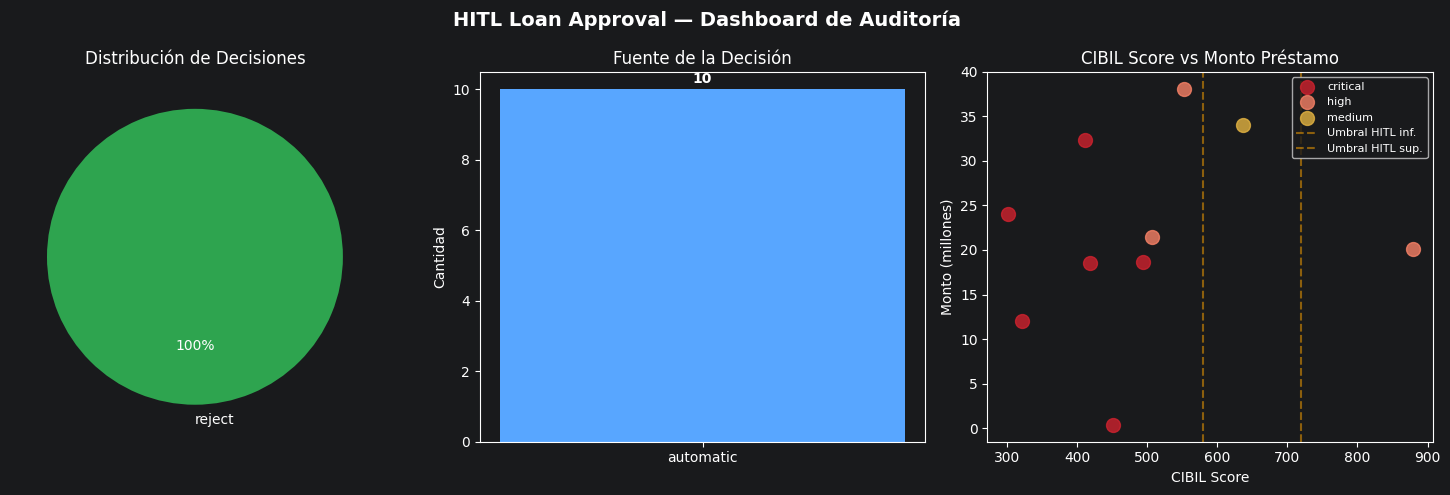

✅ Dashboard guardado como hitl_dashboard.png


In [19]:
# ============================================================
# CELDA 19 — Dashboard de auditoría: decisiones tomadas
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("HITL Loan Approval — Dashboard de Auditoría", fontsize=14, fontweight="bold")

# Gráfico 1: Distribución de decisiones finales
decision_counts = results_df["final_decision"].value_counts()
colors_dec = ["#2ea44f", "#cf222e", "#e3b341", "#1f6feb"]
axes[0].pie(
    decision_counts.values,
    labels=decision_counts.index,
    autopct="%1.0f%%",
    colors=colors_dec[:len(decision_counts)],
    startangle=90
)
axes[0].set_title("Distribución de Decisiones")

# Gráfico 2: Fuente de decisión (automática vs HITL)
source_counts = results_df["source"].value_counts()
bars = axes[1].bar(source_counts.index, source_counts.values,
                   color=["#58a6ff", "#f78166", "#3fb950"])
axes[1].set_title("Fuente de la Decisión")
axes[1].set_ylabel("Cantidad")
for bar, val in zip(bars, source_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Scatter CIBIL Score vs Monto por riesgo
risk_colors = {"low": "#3fb950", "medium": "#e3b341", "high": "#f78166", "critical": "#cf222e"}
for risk in results_df["risk_level"].unique():
    subset = results_df[results_df["risk_level"] == risk]
    axes[2].scatter(
        subset["cibil_score"],
        subset["loan_amount"] / 1_000_000,
        label=risk,
        color=risk_colors.get(risk, "gray"),
        s=100, alpha=0.8
    )
axes[2].set_title("CIBIL Score vs Monto Préstamo")
axes[2].set_xlabel("CIBIL Score")
axes[2].set_ylabel("Monto (millones)")
axes[2].axvline(x=580, color="orange", linestyle="--", alpha=0.5, label="Umbral HITL inf.")
axes[2].axvline(x=720, color="orange", linestyle="--", alpha=0.5, label="Umbral HITL sup.")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("hitl_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard guardado como hitl_dashboard.png")

### Inspección del estado persistido en el checkpointer
(Muestra el poder del checkpointing para auditoría)

In [20]:
# ============================================================
# CELDA 20 — Inspección del estado persistido en el checkpointer
# (Muestra el poder del checkpointing para auditoría)
# ============================================================

print("=" * 60)
print("CHECKPOINTER — Estado persistido (thread loan-LP042)")
print("=" * 60)

# Ver el estado completo guardado en el checkpointer
checkpoint_state = graph.get_state(config_2)

print(f"Thread ID: {config_2['configurable']['thread_id']}")
print(f"Pasos ejecutados: {len(checkpoint_state.values.get('decision_log', []))}")
print(f"Decisión final: {checkpoint_state.values.get('final_decision')}")
print(f"Risk Score: {checkpoint_state.values.get('risk_score')}")
print(f"AI Reasoning: {checkpoint_state.values.get('ai_reasoning', '')[:120]}...")

# Historial de checkpoints del thread
history = list(graph.get_state_history(config_2))
print(f"\nTotal checkpoints en el thread: {len(history)}")
for i, h in enumerate(history[:3]):
    print(f"  [{i}] step={h.metadata.get('step', '?')} → next={h.next}")

CHECKPOINTER — Estado persistido (thread loan-LP042)
Thread ID: loan-LP042-v2
Pasos ejecutados: 3
Decisión final: approve
Risk Score: 0.65
AI Reasoning: CIBIL score de 658 está en rango medio que requiere revisión humana. Ratio préstamo/ingreso de 5x es elevado pero acepta...

Total checkpoints en el thread: 5
  [0] step=3 → next=()
  [1] step=2 → next=('finalize_human',)
  [2] step=1 → next=('human_review',)


### Exportar resultados a CSV con audit trail

In [21]:
# ============================================================
# CELDA 21 — Exportar resultados a CSV con audit trail
# ============================================================
from datetime import datetime

# Exportar tabla de decisiones
output_path = f"loan_decisions_{datetime.now().strftime('%Y%m%d_%H%M')}.csv"
results_df.to_csv(output_path, index=False)
print(f"✅ Resultados exportados: {output_path}")
print(results_df.to_string(index=False))

print("""
╔══════════════════════════════════════════════════════════════╗
║          RESUMEN DEL PATRÓN HITL — LangGraph                ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  interrupt()     → pausa el grafo, serializa estado         ║
║  MemorySaver     → persiste estado entre invocaciones        ║
║  Command(resume) → reanuda desde el punto de pausa          ║
║  thread_id       → identifica sesiones independientes       ║
║                                                              ║
║  Cuándo HITL es OBLIGATORIO:                                 ║
║  • Acciones irreversibles (aprobar créditos, deploy, delete) ║
║  • Zona gris (CIBIL 580-720 en este caso)                   ║
║  • Montos que superan umbral de política                     ║
║  • Compliance y regulaciones financieras                    ║
╚══════════════════════════════════════════════════════════════╝
""")

✅ Resultados exportados: loan_decisions_20260524_1729.csv
loan_id  cibil_score  loan_amount risk_level ai_recommendation final_decision    source   thread_id
  LP014          451       361087   critical            reject         reject automatic batch-LP014
  LP016          419     18573392   critical            reject         reject automatic batch-LP016
  LP023          411     32348740   critical            reject           None automatic batch-LP023
  LP043          321     12018070   critical            reject         reject automatic batch-LP043
  LP031          879     20072981       high            reject         reject automatic batch-LP031
  LP028          637     34079713     medium            review           None automatic batch-LP028
  LP002          301     23985747   critical            reject         reject automatic batch-LP002
  LP021          553     38114054       high            reject           None automatic batch-LP021
  LP011          507     21500096       hi